# Model alpha parameter analysis


# # lotka volterra 

$$ \frac{dP}{dt}= r_p \cdot P - \alpha \cdot C\cdot P  $$

   $$ \frac{dC}{dt}= \alpha C\cdot P - \nu \cdot C $$


In [13]:
import pandas as pd

# Path to experimental data file
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'

# Load the Excel file into a DataFrame
df3 = pd.read_excel(file_path3)

# Extract time (first column) and experimental population data (last column)
time_data = df3.iloc[:, 0]        # Time points
exp_data = df3.iloc[:, -1]        # Experimental measurements (e.g., cooperator population)


In [4]:
df3.iloc[:46]

,Time [h],Count 4018 C. glutamicum [-]\nChamber 01,Count 4018 C. glutamicum [-]\nChamber 02,Count 4018 C. glutamicum [-]\nChamber 03,Count 4018 C. glutamicum [-]\nChamber 04,Count 4018 C. glutamicum [-]\nChamber 05,Count 4018 C. glutamicum [-]\nChamber 06,Count 4018 C. glutamicum [-]\nChamber 07,Count 4018 C. glutamicum [-]\nChamber 08,Count 4018 C. glutamicum [-]\nChamber 09,...,Count 4056 E. coli WT [-]\nChamber 02,Count 4056 E. coli WT [-]\nChamber 03,Count 4056 E. coli WT [-]\nChamber 04,Count 4056 E. coli WT [-]\nChamber 05,Count 4056 E. coli WT [-]\nChamber 06,Count 4056 E. coli WT [-]\nChamber 07,Count 4056 E. coli WT [-]\nChamber 08,Count 4056 E. coli WT [-]\nChamber 09,Count 4056 E. coli WT [-]\nChamber 10,Average count 4056 E.coli WT [-]\nChamber 01-10
0,0.000000,11,20,15,13,14,8,15,7,14,...,2,2,2,4,2,2,1,2,2.0,2.4
1,0.333333,11,19,18,17,20,13,18,7,20,...,2,2,2,4,2,2,1,3,2.0,2.6
2,0.666667,14,27,28,18,22,15,23,11,23,...,2,3,2,5,2,2,1,3,2.0,2.7
3,1.000000,15,34,26,23,31,20,26,13,27,...,2,2,3,6,2,2,1,4,1.0,3.0
4,1.333333,18,40,27,24,41,22,31,14,37,...,3,2,4,8,4,3,1,4,2.0,3.9
5,1.666667,23,51,35,24,42,27,36,17,38,...,3,2,4,8,4,4,2,4,2.0,4.2
6,2.000000,28,60,45,27,52,32,48,20,46,...,4,3,4,8,4,4,3,4,2.0,4.5
7,2.333333,28,66,45,27,64,39,55,21,55,...,5,4,4,9,4,6,5,7,3.0,5.7
8,2.666667,34,72,47,34,75,40,57,21,63,...,7,4,4,10,7,5,7,8,2.0,6.7
9,3.000000,40,77,49,34,82,43,61,30,74,...,7,4,4,13,8,5,6,8,3.0,7.1



 Optimization Results
Success: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Fitted Parameters:
  beta = 0.00010
  gamma = 0.00010
  alpha = 0.00343
  eta = 0.00096
  r_c = 0.47699
  r_p = 0.20000
  nu = 0.00615
  sigma_c = 0.10000
  sigma_p = 0.10000


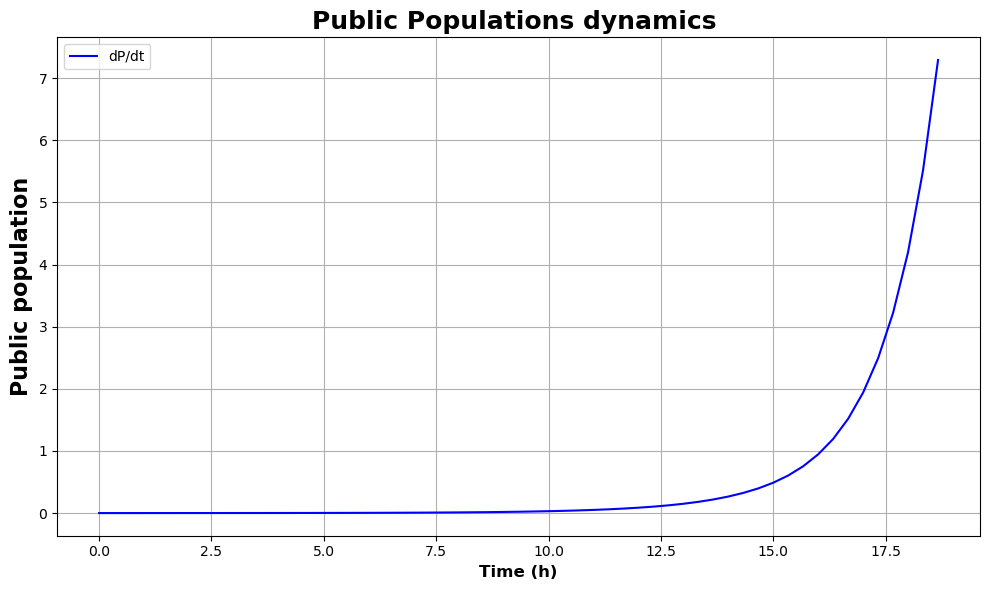

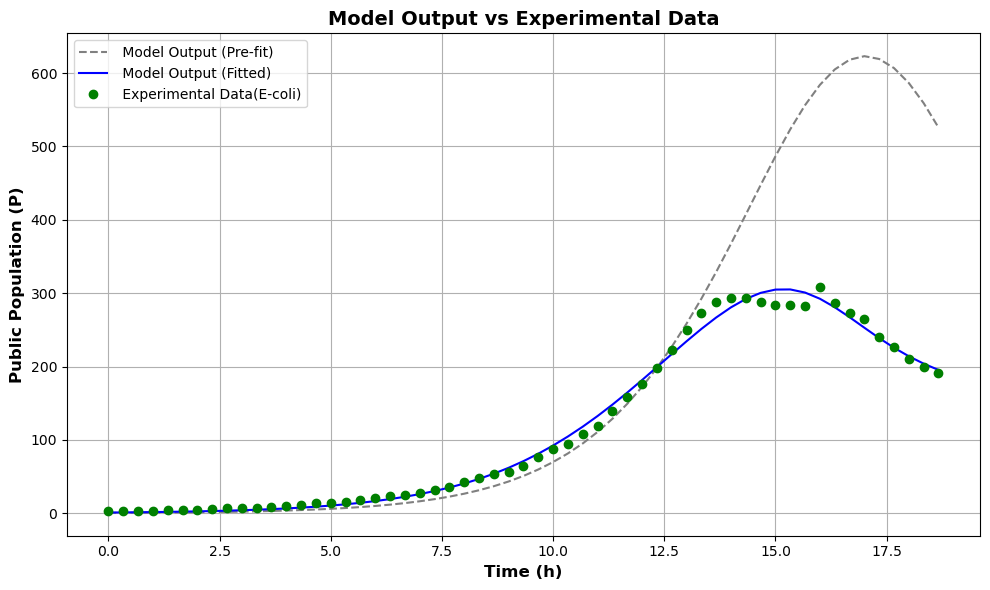

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from src.parameters import parameters  # your original parameter dictionary

# -----------------------
# 1. Define ODE System
# -----------------------
def deriv(t, y, params):
    P, C = y
    dP = (params["r_c"] * P 
          - params["alpha"] * C * P  
          - params["eta"] * P**2)
    dC = (params["alpha"] * C * P 
          - params["nu"] * C**2)
    return [dP, dC]


# 2. Load Experimental Data
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'
df3 = pd.read_excel(file_path3)

time_data = df3.iloc[:, 0].values        # Time
exp_data = df3.iloc[:, -1].values        # Experimental C population

initial_conditions = [1, 1]

pre_fit_sol = solve_ivp(
    deriv,
    [time_data[0], time_data[-1]],
    initial_conditions,
    t_eval=time_data,
    args=(parameters,),
    method='RK45'
)

C_pre, D_pre = pre_fit_sol.y
dP_vals, dC_vals = np.array([deriv(t, y, parameters) for t, y in zip(time_data, pre_fit_sol.y.T)]).T

# 5. Define Residual for Optimization
def residual(param_values, data, model_template):
    model = model_template.copy()
    for i, key in enumerate(model.keys()):
        model[key] = param_values[i]
    
    sol = solve_ivp(deriv, [time_data[0], time_data[-1]], initial_conditions,
                    t_eval=time_data, args=(model,), method='RK45')
    
    if not sol.success:
        return 1e6

    P_pred = sol.y[0]
    rmse = np.sqrt(np.mean((data - P_pred)**2))
    return rmse

# 6. Optimization
initial_guess = list(parameters.values())
sol = minimize(residual, x0=initial_guess,
               args=(exp_data, parameters), method='L-BFGS-B')

print("\n Optimization Results")
print("Success:", sol.success)
print("Message:", sol.message)
print("Fitted Parameters:")
for name, val in zip(parameters.keys(), sol.x):
    print(f"  {name} = {val:.5f}")

# 7. Simulate with Fitted Parameters
fitted_params = dict(zip(parameters.keys(), sol.x))

post_fit_sol = solve_ivp(
    deriv,
    [time_data[0], time_data[-1]],
    initial_conditions,
    t_eval=time_data,
    args=(fitted_params,),
    method='RK45'
)

P_post, C_post = post_fit_sol.y

plt.figure(figsize=(10,6))
plt.plot(time_data, dC_vals, label='dP/dt', color='blue')
plt.xlabel('Time (h)', fontsize=12, fontweight='bold')
plt.ylabel('Public population', fontsize=16, fontweight='bold')
plt.title('Public Populations dynamics ', fontsize=18, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 9. Plot Model Outputs (Pre/Post Fit) + Experimental Data
plt.figure(figsize=(10,6))
plt.plot(time_data, dP_vals, label=' Model Output (Pre-fit)', color='gray', linestyle='--')
plt.plot(time_data, P_post, label=' Model Output (Fitted)', color='blue')
plt.plot(time_data, exp_data, 'go', label=' Experimental Data(E-coli)')
plt.xlabel('Time (h)', fontsize=12, fontweight='bold')
plt.ylabel('Public Population (P)', fontsize=12, fontweight='bold')
plt.title('Model Output vs Experimental Data', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Alpha graph analysis

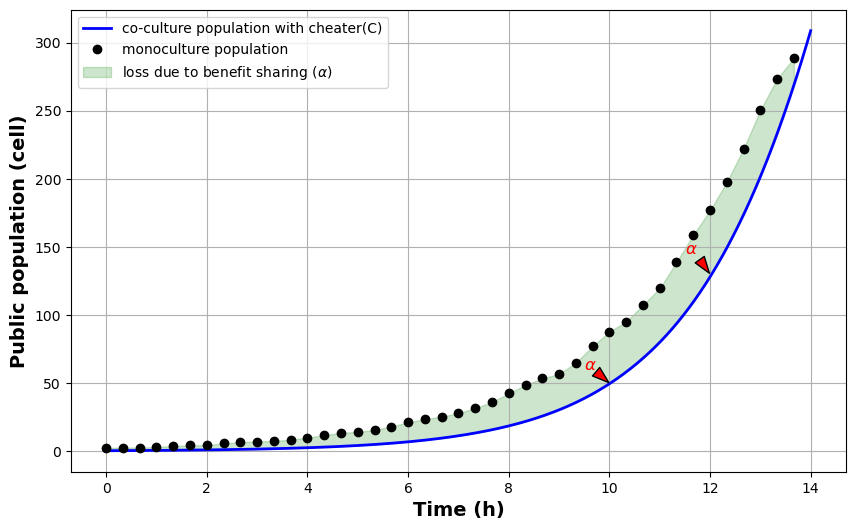

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.integrate import solve_ivp
from src.parameters import parameters

# Define the System of ODEs
def deriv(t, y, params):
     P,C = y
    dP = (params["r_c"] * P
          - params["alpha"] * C * P
          - params["eta"] * P**2)
    dC = (params["alpha"] * C * P
          - params["nu"] * C**2)
    return [dC, dP]

# Simulation Parameters
T = 14                # Total simulation time

initial_conditions = [1,1]
time = np.linspace(0, T, 1000)  # Time points for evaluation

# Solve the ODE System
solution = solve_ivp(
    deriv,
    [0, T],
    initial_conditions,
    t_eval=time,
    args=(parameters,),
    method="RK45"
)

# Extract Results
C_sol, P_sol = solution.y

# Read the experimental data
file_path3 = r'C:\Users\Tanvir Hassan\4018 C. glutamicum WT + 4056 E.coli WT.xlsx'
df3 = pd.read_excel(file_path3)

# Select the first and last columns from the second file
first_column_3 = df3.iloc[:, 0]  # Time
last_column_3  = df3.iloc[:, -1] # Data to plot

# Find the maximum value in the experimental data
max_value = last_column_3.max()

# Normalize the simulation results by the maximum value of the experimental data
C_sol_normalized = C_sol / C_sol.max() * max_value
P_sol_normalized = P_sol / P_sol.max() * max_value

# Convert the experimental columns to numpy for convenience
x_exp = first_column_3.iloc[:42].to_numpy()
y_exp = last_column_3.iloc[:42].to_numpy()

# --- Interpolate simulation results at the experimental time points ---
#    This aligns them in time so you can fill between the two curves.
y_sim_at_data_points = np.interp(x_exp, time, C_sol_normalized)

# Plot the Results
plt.figure(figsize=(10, 6))

# (1) Plot the simulation (green line)
plt.plot(time, C_sol_normalized,
         label='co-culture population with cheater(C)',
         color='b', linestyle='-', linewidth=2)

# (2) Plot the experimental data (black markers)
plt.plot(x_exp, y_exp,
         label='monoculture population',
         color='black', marker='o', linestyle='None')

# (3) Fill the area between the two curves (green shading)
#     We only fill where we have experimental data (0 to x_exp[-1]).
x_fill = x_exp
y1_fill = y_sim_at_data_points
y2_fill = y_exp

plt.fill_between(x_fill, y1_fill, y2_fill,
                 color='green', alpha=0.2,
                 label='loss due to benefit sharing ($\\alpha$)')

# Add arrows to indicate the effect of alpha
arrow_params = dict(facecolor="red", shrink=0.05, width=2, headwidth=8)
plt.annotate(r"$\alpha$",
             xy=(10, 50), xytext=(9.5, 60),
             arrowprops=arrow_params, fontsize=12, color='red')
plt.annotate(r"$\alpha$",
             xy=(12, 130), xytext=(11.5, 145),
             arrowprops=arrow_params, fontsize=12, color='red')

# Customize plot
plt.xlabel('Time (h)', fontsize=14, fontweight='bold')
plt.ylabel('Public population (cell)', fontsize=14, fontweight='bold')
#plt.title('Comparison of Public Metabolizer in Mono vs. Co-culture', fontsize=14)
plt.legend()
plt.grid(True)

# Save figure
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/alpha_analysis_shaded.png", dpi=300)

# Show the plot
plt.show()
